In [1]:
print("Exercise 1")

Exercise 1


In [3]:
import numpy as np

matrix = np.random.randint(1, 101, size=(5, 5))


print("5x5 Matrix:\n", matrix)

print("\nTransposed Matrix:\n", matrix.T)

print("\nRow Sums:", matrix.sum(axis=1))
print("Column Sums:", matrix.sum(axis=0))

max_idx = np.unravel_index(np.argmax(matrix), matrix.shape)
print(f"\nMax value is {matrix[max_idx]} located at row {max_idx[0]}, col {max_idx[1]}")

5x5 Matrix:
 [[33  5 69 67 63]
 [38 77 57 94 91]
 [28 92 35 26 30]
 [81 22 20 40 65]
 [69 43 62 84 89]]

Transposed Matrix:
 [[33 38 28 81 69]
 [ 5 77 92 22 43]
 [69 57 35 20 62]
 [67 94 26 40 84]
 [63 91 30 65 89]]

Row Sums: [237 357 211 228 347]
Column Sums: [249 239 243 311 338]

Max value is 94 located at row 1, col 3


In [4]:
import numpy as np
import pandas as pd

data = {
    'Name': ['Dhruva', 'Aakash', 'Ashvik', 'Shourya', 'Safin', 'Raiyhan', 'Eshaan',
             'Khushi', 'Manan', 'Parth', 'Tanish', 'Dhruv', 'Navya', 'Yashasvini',
             'Aarushi', 'Arunachala', 'Abhimanyu'],
    'Subject': ['Maths', 'MOS', 'MOS', 'BE', 'BME', 'MOS', 'Maths', 'MOS', 'EG',
                'BE', 'BME', 'MOS', 'EG', 'MOS', 'EG', 'MOS', 'MOS'],
    'Marks': [82, 88, 38, 42, 36, 91, 86, 40, 59, 44, 71, 35, np.nan, 93, 79, 94, 90],
    'Attendance %': [92, 88, 81, 79, 90, 85, 42, 83, 76, 65, 68, 80, 93, 95, 62, 96, 91]
}

df = pd.DataFrame(data)


df['Marks'] = df['Marks'].fillna(df['Marks'].mean().round(1))


print("Average Marks per Subject")
print(df.groupby('Subject')['Marks'].mean().round(2))

print("\n Low Attendance (< 75%)")
print(df[df['Attendance %'] < 75][['Name', 'Attendance %']])

df['Pass/Fail'] = np.where(df['Marks'] >= 40, 'Pass', 'Fail')

top_5 = df.nlargest(5, 'Marks')
print("\n Top 5 Students ")
print(top_5[['Name', 'Marks', 'Pass/Fail']])


Average Marks per Subject
Subject
BE       43.00
BME      53.50
EG       68.27
MOS      71.12
Maths    84.00
Name: Marks, dtype: float64

 Low Attendance (< 75%)
       Name  Attendance %
6    Eshaan            42
9     Parth            65
10   Tanish            68
14  Aarushi            62

 Top 5 Students 
          Name  Marks Pass/Fail
15  Arunachala   94.0      Pass
13  Yashasvini   93.0      Pass
5      Raiyhan   91.0      Pass
16   Abhimanyu   90.0      Pass
1       Aakash   88.0      Pass


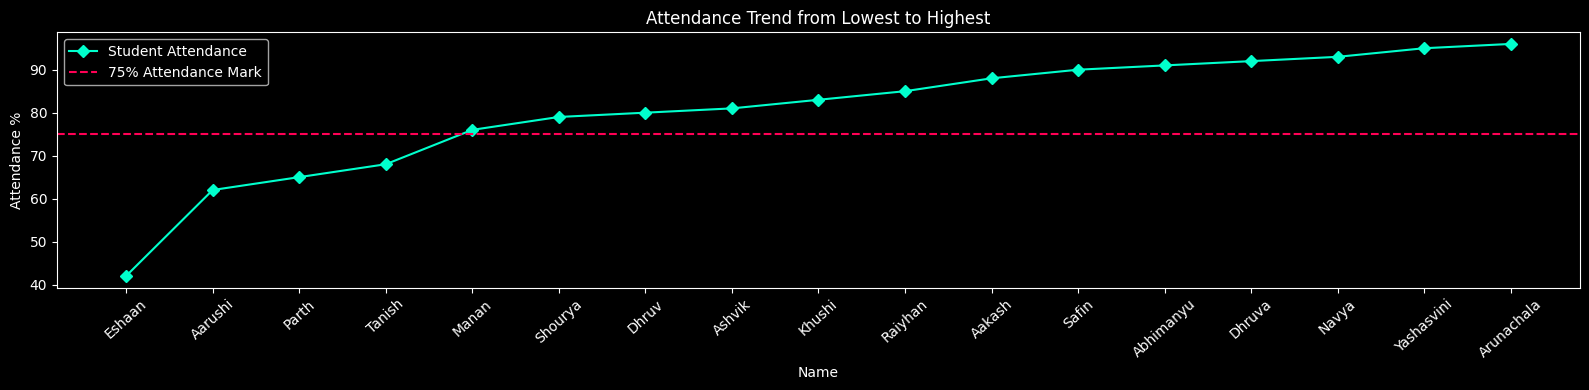

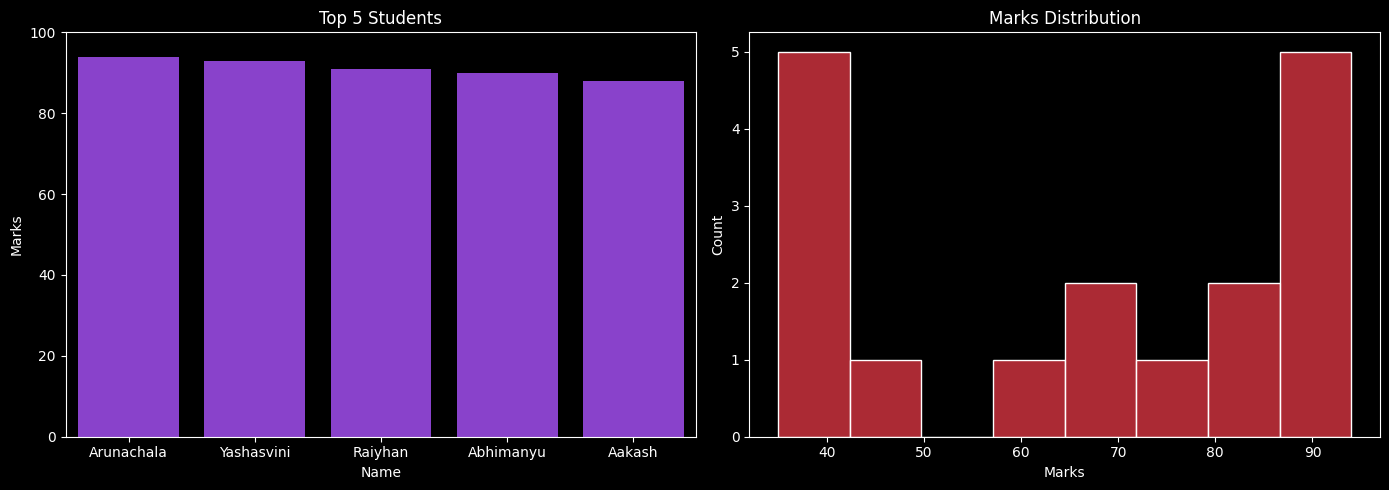

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')


plt.figure(figsize=(16, 4))
trend_df = df.sort_values('Attendance %')

plt.plot(trend_df['Name'], trend_df['Attendance %'], color='#00ffcc', marker='D', markersize=6, label='Student Attendance')

plt.axhline(75, color='#ff0055', linestyle='--', linewidth=1.5, label='75% Attendance Mark')

plt.title('Attendance Trend from Lowest to Highest')
plt.xlabel('Name')
plt.ylabel('Attendance %')
plt.xticks(rotation=42)
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top_5, x='Name', y='Marks', ax=axes[0], color='#8a2be2')
axes[0].set_title('Top 5 Students')
axes[0].set_ylim(0, 100)

sns.histplot(data=df, x='Marks', bins=8, ax=axes[1], color='#e63946', edgecolor='white')
axes[1].set_title('Marks Distribution')

plt.tight_layout()
plt.show()

In [6]:
print("Exercise 2")

Exercise 2


In [7]:
import pandas as pd
import numpy as np

df_2015 = pd.read_csv('data/2015.csv')
df_2016 = pd.read_csv('data/2016.csv')
df_2017 = pd.read_csv('data/2017.csv')
df_2018 = pd.read_csv('data/2018.csv')
df_2019 = pd.read_csv('data/2019.csv')

region_map = dict(zip(df_2015['Country'], df_2015['Region']))
region_map.update(dict(zip(df_2016['Country'], df_2016['Region'])))

d15 = df_2015[['Country', 'Region', 'Happiness Score', 'Economy (GDP per Capita)', 'Health (Life Expectancy)', 'Freedom']].copy()
d15.columns = ['Country', 'Region', 'Score', 'GDP', 'Life_Expectancy', 'Freedom']
d15['Year'] = 2015

d16 = df_2016[['Country', 'Region', 'Happiness Score', 'Economy (GDP per Capita)', 'Health (Life Expectancy)', 'Freedom']].copy()
d16.columns = ['Country', 'Region', 'Score', 'GDP', 'Life_Expectancy', 'Freedom']
d16['Year'] = 2016

d17 = df_2017[['Country', 'Happiness.Score', 'Economy..GDP.per.Capita.', 'Health..Life.Expectancy.', 'Freedom']].copy()
d17.columns = ['Country', 'Score', 'GDP', 'Life_Expectancy', 'Freedom']
d17['Region'] = d17['Country'].map(region_map)
d17['Year'] = 2017

d18 = df_2018[['Country or region', 'Score', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices']].copy()
d18.columns = ['Country', 'Score', 'GDP', 'Life_Expectancy', 'Freedom']
d18['Region'] = d18['Country'].map(region_map)
d18['Year'] = 2018

d19 = df_2019[['Country or region', 'Score', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices']].copy()
d19.columns = ['Country', 'Score', 'GDP', 'Life_Expectancy', 'Freedom']
d19['Region'] = d19['Country'].map(region_map)
d19['Year'] = 2019

all_years = pd.concat([d15, d16, d17, d18, d19], ignore_index=True)

all_years['Region'] = all_years['Region'].fillna('Other')
all_years['Score'] = pd.to_numeric(all_years['Score'], errors='coerce')

print("Loaded and standardized all 5 years successfully!")
print(all_years.head())


FileNotFoundError: [Errno 2] No such file or directory: 'data/2015.csv'

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

h_2015 = d15.sort_values('Score', ascending=False).iloc[0]['Country']
l_2015 = d15.sort_values('Score', ascending=True).iloc[0]['Country']
h_2019 = d19.sort_values('Score', ascending=False).iloc[0]['Country']
l_2019 = d19.sort_values('Score', ascending=True).iloc[0]['Country']

tracked_countries = list(set([h_2015, l_2015, h_2019, l_2019]))
print("i: Countries:", tracked_countries)

df_tracked = all_years[all_years['Country'].isin(tracked_countries)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['Score', 'GDP', 'Life_Expectancy']
titles = ['Happiness Score Trend', 'GDP per Capita Trend', 'Life Expectancy Trend']

for i, feat in enumerate(features):
    sns.lineplot(data=df_tracked, x='Year', y=feat, hue='Country', marker='o', ax=axes[i], palette='bright')
    axes[i].set_title(titles[i])
    axes[i].set_xticks([2015, 2016, 2017, 2018, 2019])
plt.tight_layout()
plt.show()


region_avg = all_years.groupby('Region')['Score'].mean().sort_values(ascending=False)
print("\n ii: Regional Average Happiness (All 5 Years)")
print(region_avg)

plt.figure(figsize=(10, 5))
sns.barplot(x=region_avg.values, y=region_avg.index, hue=region_avg.index, legend=False)
plt.title('Happiest Regions of the World (5-Year Average)')
plt.xlabel('Average Happiness Score')
plt.tight_layout()
plt.show()


top10_per_year = all_years.groupby('Year').apply(lambda x: x.nlargest(10, 'Score')).reset_index(drop=True)
region_comp = top10_per_year['Region'].value_counts()
print("\n iii: Top 10 Countries Region-wise Composition")
print(region_comp)

plt.figure(figsize=(8, 5))
plt.pie(region_comp, labels=region_comp.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Region Composition of Top 10 Countries Across All 5 Years')
plt.show()


lac_df = all_years[all_years['Region'] == 'Latin America and Caribbean']

lac_each_year = lac_df.loc[lac_df.groupby('Year')['Score'].idxmax()][['Year', 'Country', 'Score']]
print("\niv:a) (Each Year):")
print(lac_each_year)

lac_overall = lac_df.groupby('Country')['Score'].mean().sort_values(ascending=False).head(1)
print("\niv:b) (Overall 5 Years):")
print(lac_overall)

NameError: name 'd15' is not defined